<a href="https://colab.research.google.com/github/swirita/Chicago-Crime-Analysis-and-Forecasting/blob/main/notebooks/03_crime_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crime Forecasting
- Author: Siwar Ehwass

## Overview
Chicago law enforcement needs a six-month crime forecast to help allocate staff and other resources. This notebook compares monthly forecasts for **Theft** and **Battery**, two high-volume crime categories.

## Imports

In [1]:
!pip install pmdarima

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error

import statsmodels.api as sm
import statsmodels.tsa.api as tsa
import pmdarima as pm
from pmdarima.arima.utils import ndiffs, nsdiffs
from pmdarima.model_selection import train_test_split
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

## Custom Functions

In [2]:
# Same colors and chart style used in the analysis notebook.
COLORS = {
    "main": "#243B53",
    "secondary": "#5B8DB8",
    "warning": "#E9A23B",
    "background": "#F7F8FA",
    "text": "#263238",
}

CRIME_COLORS = {
    "THEFT": COLORS["main"],
    "BATTERY": COLORS["secondary"],
}

plt.rcParams.update({
    "figure.figsize": (16, 5),
    "figure.dpi": 120,
    "figure.facecolor": COLORS["background"],
    "axes.facecolor": COLORS["background"],
    "font.size": 11,
})


def style_chart(ax, title, xlabel="", ylabel=""):
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.set_title(
        title,
        loc="left",
        fontsize=15,
        fontweight="bold",
        color=COLORS["text"],
        pad=15,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

In [3]:
def plot_forecast(
    ts_train,
    ts_test,
    forecast_df,
    n_train_lags=None,
    figsize=(14, 5),
    title="Forecast vs. Actual Data",
):
    fig, ax = plt.subplots(figsize=figsize)

    if n_train_lags is None:
        n_train_lags = len(ts_train)

    # Historical data
    ts_train.iloc[-n_train_lags:].plot(
        ax=ax,
        color=COLORS["main"],
        linewidth=2,
        label="Training data",
    )

    # Test data, when available
    if ts_test is not None:
        ts_test.plot(
            ax=ax,
            color=COLORS["text"],
            marker="o",
            linewidth=2,
            label="Actual test data",
        )

    # Forecast
    forecast_df["mean"].plot(
        ax=ax,
        color=COLORS["warning"],
        marker="o",
        linestyle="--",
        linewidth=2,
        label="Forecast",
    )

    # Confidence interval
    ax.fill_between(
        forecast_df.index,
        forecast_df["mean_ci_lower"].to_numpy(),
        forecast_df["mean_ci_upper"].to_numpy(),
        color=COLORS["warning"],
        alpha=0.20,
        label="95% confidence interval",
    )

    style_chart(
        ax,
        title,
        xlabel="Month",
        ylabel="Number of crimes",
    )

    ax.legend(frameon=False, ncol=2)
    plt.show()

    return fig, ax

In [4]:
def adf_summary(series, label):
    statistic, p_value, used_lags, observations, *_ = adfuller(series.dropna())
    result = pd.DataFrame({
        "Series": [label],
        "ADF statistic": [statistic],
        "p-value": [p_value],
        "Lags used": [used_lags],
        "Observations": [observations],
        "Stationary?": [p_value < 0.05],
    })
    return result.set_index("Series")

In [5]:
### NEW FUNCTION FOR COMBINED ACF/PACF WITH ANNOTATIONS
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)

    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')
    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )
    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)

    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")
        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m
        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")
    fig.tight_layout()

    return fig


In [6]:
def make_stationary(series, d, D, season_length=12):
    stationary = series.copy()

    for _ in range(D):
        stationary = stationary.diff(season_length)

    for _ in range(d):
        stationary = stationary.diff()

    return stationary.dropna()

In [7]:

def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = root_mean_squared_error(ts_true, ts_pred)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

In [8]:
def plot_decomposition(decomposition, crime_name, color):
    parts = {
        "Observed": decomposition.observed,
        "Trend": decomposition.trend,
        "Seasonal": decomposition.seasonal,
        "Residual": decomposition.resid,
    }

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    for ax, (label, values) in zip(axes, parts.items()):
        ax.plot(values.index, values, color=color, linewidth=1.5)
        style_chart(ax, label, ylabel="Crime count")

    fig.suptitle(
        f"{crime_name.title()} Monthly Time-Series Decomposition",
        x=0.125,
        ha="left",
        fontsize=17,
        fontweight="bold",
        color=COLORS["text"],
    )
    fig.tight_layout()
    plt.show()

In [9]:
def plot_test_forecast(train, test, forecast, crime_name, model_name, color):
    fig, ax = plt.subplots(figsize=(14, 5))

    train.tail(36).plot(ax=ax, color=COLORS["main"], label="Training data")
    test.plot(ax=ax, color=COLORS["text"], marker="o", label="Actual test data")
    forecast["Forecast"].plot(
        ax=ax,
        color=color,
        marker="o",
        linestyle="--",
        label="Forecast",
    )
    ax.fill_between(
        forecast.index,
        forecast["Lower CI"],
        forecast["Upper CI"],
        color=color,
        alpha=0.18,
        label="95% confidence interval",
    )

    style_chart(
        ax,
        f"{crime_name.title()}: {model_name} Forecast vs. Actual",
        xlabel="Month",
        ylabel="Number of crimes",
    )
    ax.legend(frameon=False, ncol=2)
    plt.show()


In [10]:
def forecast_frame(prediction, index):
    intervals = prediction.conf_int()
    return pd.DataFrame({
        "Forecast": np.asarray(prediction.predicted_mean),
        "Lower CI": np.asarray(intervals.iloc[:, 0]),
        "Upper CI": np.asarray(intervals.iloc[:, 1]),
    }, index=index).clip(lower=0)

In [11]:
def regression_metrics(actual, predicted, model_name):
    actual = pd.Series(actual)
    predicted = pd.Series(predicted, index=actual.index)

    return {
        "Model": model_name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "MAPE (%)": mean_absolute_percentage_error(actual, predicted) * 100,
        "R²": r2_score(actual, predicted),
    }

## Model Settings


In [12]:
SELECTED_CRIMES = ["THEFT", "BATTERY"]
TEST_MONTHS = 6
SEASON_LENGTH = 12

# Initial manual p, q, P, and Q values.
# d and D are determined from stationarity tests later.
MANUAL_ORDERS = {
    "THEFT": {"p": 0, "q": 1, "P": 1, "Q": 0},
    "BATTERY": {"p": 1, "q": 1, "P": 1, "Q": 1},
}

## Load & Explore Data

In [13]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
DATA_FOLDER = Path(
    "/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw"
)

crime_files = sorted(DATA_FOLDER.glob("Chicago-Crime_*.csv"))

if not crime_files:
    raise FileNotFoundError(
        f"No crime CSV files were found in {DATA_FOLDER}. Check the folder path."
    )

print(f"Found {len(crime_files)} files.")

Found 26 files.


In [15]:
def load_crime_file(file_path):
    data = pd.read_csv(
        file_path,
        usecols=["ID", "Date", "Primary Type"],
        low_memory=False
    )

    data["Date"] = pd.to_datetime(
        data["Date"],
        format="%m/%d/%Y %I:%M:%S %p",
        errors="coerce",
    )
    return data


df = pd.concat(
    [load_crime_file(file_path) for file_path in crime_files],
    ignore_index=True,
)

rows_before = len(df)
df = df.dropna(subset=["Date", "Primary Type"])
df = df.drop_duplicates(subset="ID")
df["Primary Type"] = df["Primary Type"].str.upper().str.strip()
df = df.sort_values("Date").set_index("Date")

print(f"Removed {rows_before - len(df):,} invalid, missing, or duplicate rows.")
print(f"Rows remaining: {len(df):,}")
print(f"Date range: {df.index.min():%Y-%m-%d} to {df.index.max():%Y-%m-%d}")

Removed 0 invalid, missing, or duplicate rows.
Rows remaining: 8,627,693
Date range: 2001-01-01 to 2026-08-25


In [16]:
df.head()

,ID,Primary Type
Date,,
2001-01-01,8146039,CRIM SEXUAL ASSAULT
2001-01-01,6884455,CRIM SEXUAL ASSAULT
2001-01-01,6835516,SEX OFFENSE
2001-01-01,6742268,OFFENSE INVOLVING CHILDREN
2001-01-01,6739668,THEFT


In [17]:
df.index

DatetimeIndex(['2001-01-01 00:00:00', '2001-01-01 00:00:00',
               '2001-01-01 00:00:00', '2001-01-01 00:00:00',
               '2001-01-01 00:00:00', '2001-01-01 00:00:00',
               '2001-01-01 00:00:00', '2001-01-01 00:00:00',
               '2001-01-01 00:00:00', '2001-01-01 00:00:00',
               ...
               '2026-08-25 00:00:00', '2026-08-25 00:00:00',
               '2026-08-25 00:00:00', '2026-08-25 00:00:00',
               '2026-08-25 00:00:00', '2026-08-25 00:00:00',
               '2026-08-25 00:00:00', '2026-08-25 00:00:00',
               '2026-08-25 00:00:00', '2026-08-25 00:00:00'],
              dtype='datetime64[ns]', name='Date', length=8627693, freq=None)

In [18]:
def create_monthly_series(data, crime_name):
    crime_rows = data.loc[data["Primary Type"] == crime_name]
    monthly = crime_rows.resample("MS").size().astype(float)

    # Include every month between the first and last observation.
    full_index = pd.date_range(monthly.index.min(), monthly.index.max(), freq="MS")
    monthly = monthly.reindex(full_index)

    missing_before = monthly.isna().sum()
    monthly = monthly.fillna(0)

    # A partial final month would look like an artificial crime decrease.
    latest_date = data.index.max()
    latest_month_end = latest_date.to_period("M").end_time.normalize()
    if latest_date.normalize() < latest_month_end:
        partial_month = latest_date.to_period("M").to_timestamp()
        if partial_month in monthly.index:
            monthly = monthly.drop(partial_month)
            print(
                f"{crime_name.title()}: removed incomplete month "
                f"{partial_month:%B %Y}."
            )

    monthly.name = crime_name.title()
    print(f"{crime_name.title()}: {missing_before} missing months filled with 0.")
    print(f"Remaining null values: {monthly.isna().sum()}")
    print(f"Time range: {monthly.index.min():%Y-%m} to {monthly.index.max():%Y-%m}")
    return monthly


crime_series = {
    crime: create_monthly_series(df, crime)
    for crime in SELECTED_CRIMES
}

monthly_preview = pd.concat(crime_series, axis=1).tail(12)
monthly_preview

Theft: removed incomplete month August 2026.
Theft: 0 missing months filled with 0.
Remaining null values: 0
Time range: 2001-01 to 2026-07
Battery: removed incomplete month August 2026.
Battery: 0 missing months filled with 0.
Remaining null values: 0
Time range: 2001-01 to 2026-07


,THEFT,BATTERY
2025-08-01,5000.0,3948.0
2025-09-01,4548.0,3797.0
2025-10-01,4792.0,3645.0
2025-11-01,4241.0,3404.0
2025-12-01,4158.0,3057.0
2026-01-01,3696.0,3024.0
2026-02-01,3654.0,3000.0
2026-03-01,4176.0,3416.0
2026-04-01,4119.0,3536.0
2026-05-01,4630.0,3972.0


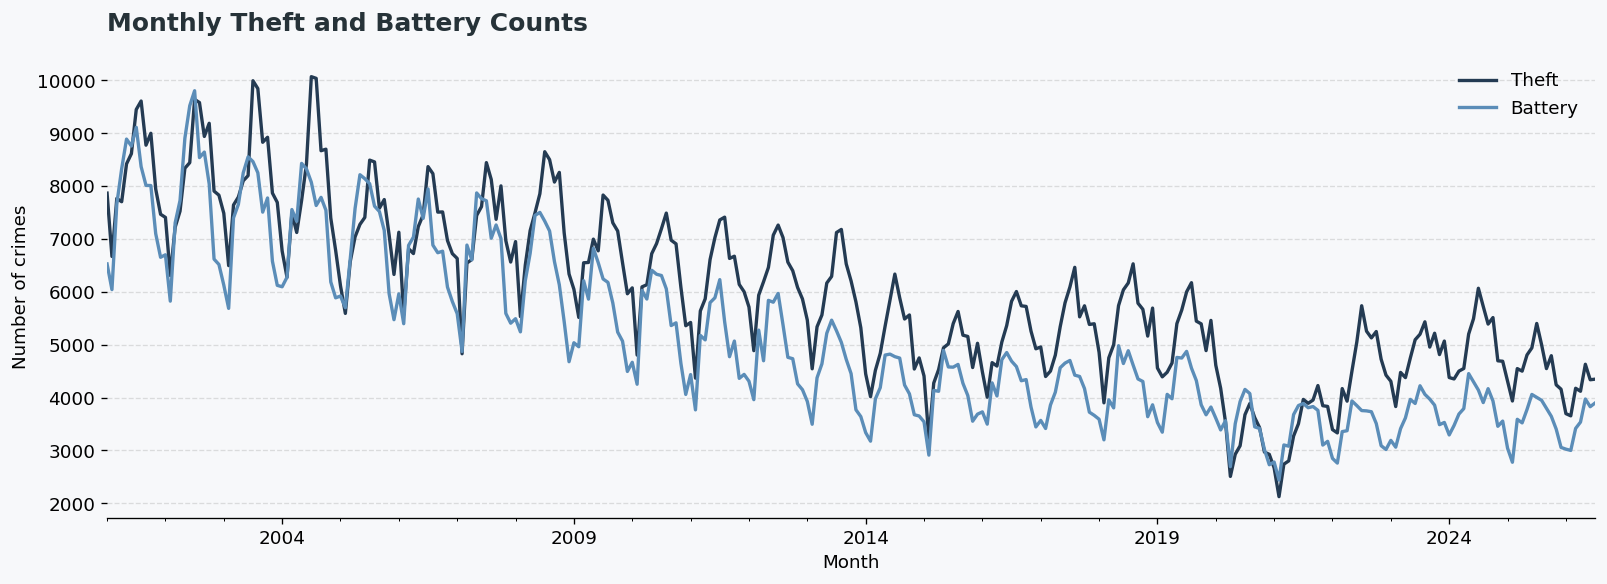

In [19]:
fig, ax = plt.subplots()

for crime, series in crime_series.items():
    series.plot(
        ax=ax,
        color=CRIME_COLORS[crime],
        linewidth=2,
        label=crime.title(),
    )

style_chart(
    ax,
    "Monthly Theft and Battery Counts",
    xlabel="Month",
    ylabel="Number of crimes",
)
ax.legend(frameon=False)
plt.show()

## 1. Theft Forecast


### 1.1 Theft: Seasonality and Decomposition

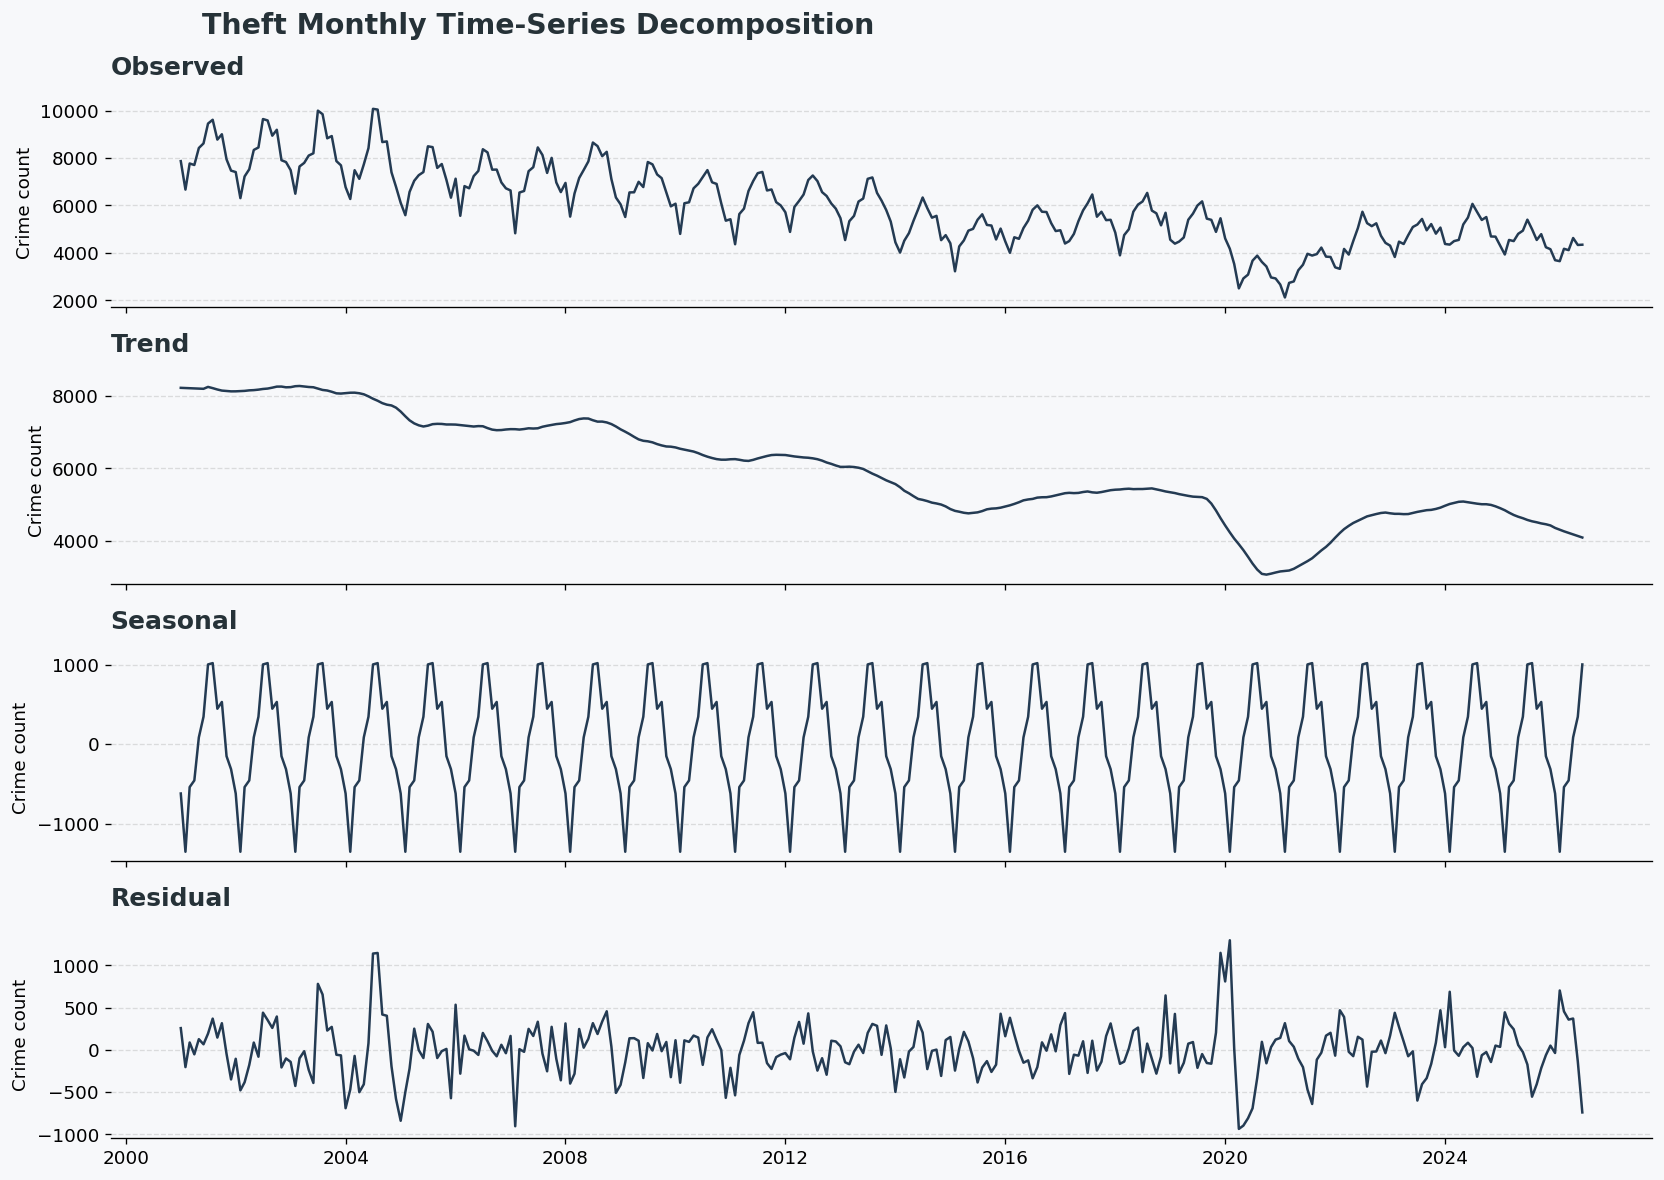

Seasonal strength: 0.819
Use a seasonal model? True


In [20]:
theft_ts = crime_series["THEFT"]
theft_decomposition = seasonal_decompose(
    theft_ts,
    model="additive",
    period=SEASON_LENGTH,
    extrapolate_trend="freq",
)

plot_decomposition(
    theft_decomposition,
    crime_name="THEFT",
    color=CRIME_COLORS["THEFT"],
)

theft_seasonal_strength = max(
    0,
    1 - (
        theft_decomposition.resid.dropna().var()
        / (theft_decomposition.seasonal + theft_decomposition.resid).dropna().var()
    ),
)

theft_use_seasonal = theft_seasonal_strength >= 0.10
print(f"Seasonal strength: {theft_seasonal_strength:.3f}")
print(f"Use a seasonal model? {theft_use_seasonal}")

**Seasonality decision:** Monthly crime can change with weather, holidays, and activity patterns across the year. The decomposition checks whether a 12-month cycle is visible. A seasonal SARIMA model is tested when the decomposition and seasonal differencing test support it; model accuracy on the six-month test set makes the final decision.

### 1.2 Theft: Differencing, Stationarity, ACF, and PACF

Recommended nonseasonal differences (d): 1
Recommended seasonal differences (D): 0


,ADF statistic,p-value,Lags used,Observations,Stationary?
Series,,,,,
Differenced Theft,-4.28244,0.000476,12,293,True


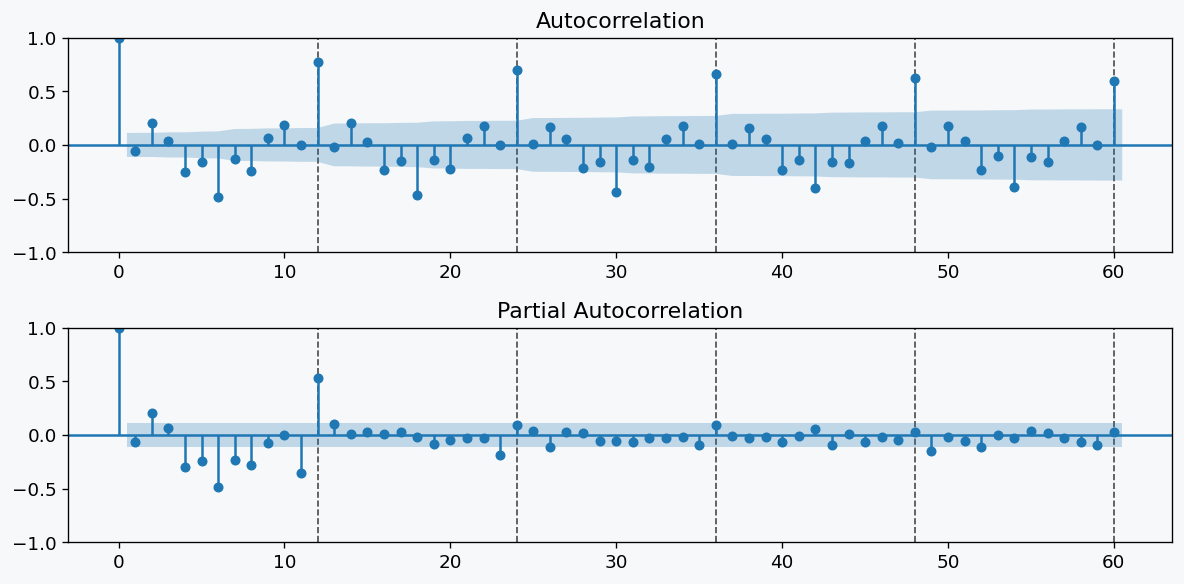

In [21]:
theft_d = ndiffs(theft_ts)
theft_D = (nsdiffs(theft_ts, m=SEASON_LENGTH))

theft_stationary = make_stationary(
    theft_ts,
    d=theft_d,
    D=theft_D,
    season_length=SEASON_LENGTH,
)

print(f"Recommended nonseasonal differences (d): {theft_d}")
print(f"Recommended seasonal differences (D): {theft_D}")
display(adf_summary(theft_stationary, "Differenced Theft"))


plot_acf_pacf(theft_stationary, annotate_seas=True, m = SEASON_LENGTH, nlags=60);

### 1.3 Theft: Train/Test Split and Manual SARIMA

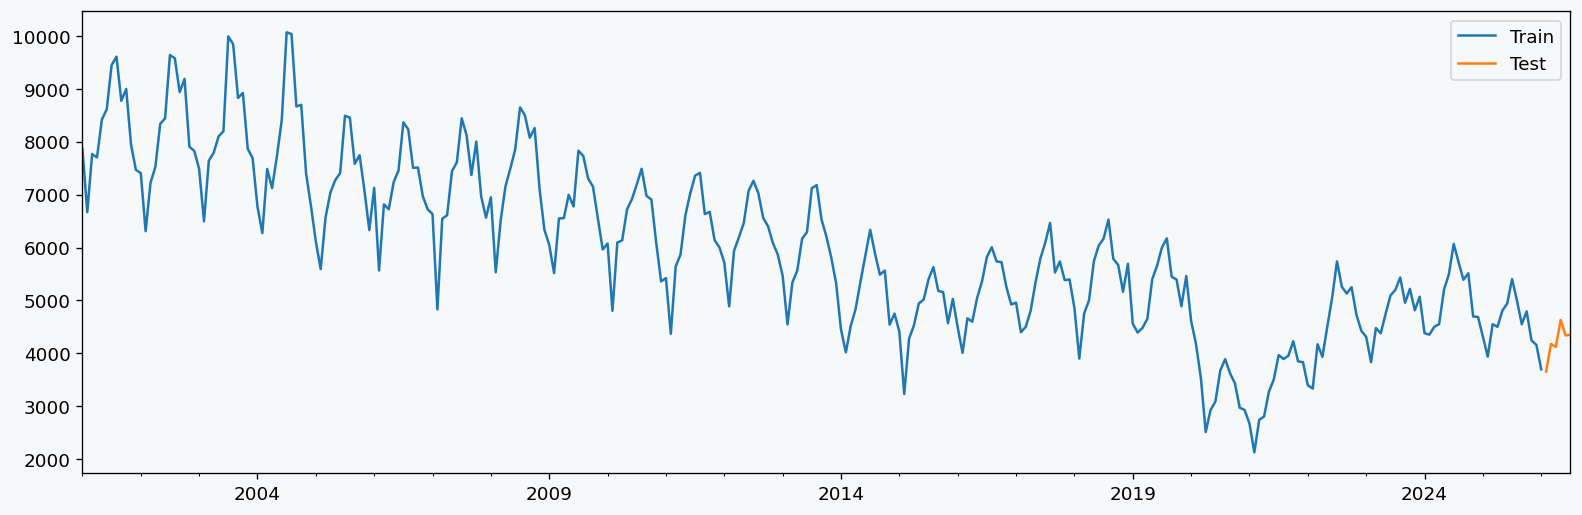

In [22]:
# tts
theft_train, theft_test = train_test_split(theft_ts, test_size=TEST_MONTHS)
ax = theft_train.plot(label='Train')
theft_test.plot(ax=ax, label='Test')
ax.legend();

In [23]:
theft_settings = MANUAL_ORDERS["THEFT"]
theft_manual_order = (
    theft_settings["p"], theft_d, theft_settings["q"]
)

theft_manual_seasonal_order = (
    theft_settings["P"], theft_D, theft_settings["Q"], SEASON_LENGTH
) if theft_use_seasonal else (0, 0, 0, 0)

print(f"Training months: {len(theft_train)}")
print(f"Test months: {len(theft_test)}")
print(f"Manual order: {theft_manual_order}")
print(f"Manual seasonal order: {theft_manual_seasonal_order}")

Training months: 301
Test months: 6
Manual order: (0, 1, 1)
Manual seasonal order: (1, 0, 0, 12)


In [24]:
theft_sarima = tsa.ARIMA(theft_train, order=theft_manual_order, seasonal_order=theft_manual_seasonal_order).fit()

In [25]:
theft_sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                             Theft   No. Observations:                  301
Model:             ARIMA(0, 1, 1)x(1, 0, [], 12)   Log Likelihood               -2197.782
Date:                           Fri, 11 Sep 2026   AIC                           4401.565
Time:                                   21:10:04   BIC                           4412.676
Sample:                               01-01-2001   HQIC                          4406.011
                                    - 01-01-2026                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2183      0.043     -5.123      0.000      -0.302      -0.135
ar.S.L12       0.7916      0.024     32.654      0.000       0.744       0.839
sigma2      1.238e+05   8428.684     14.685      0.000    1.07e+05     1.4e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                11.06
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.78   Skew:                            -0.08
Prob(H) (two-sided):                  0.21   Kurtosis:                         3.93
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

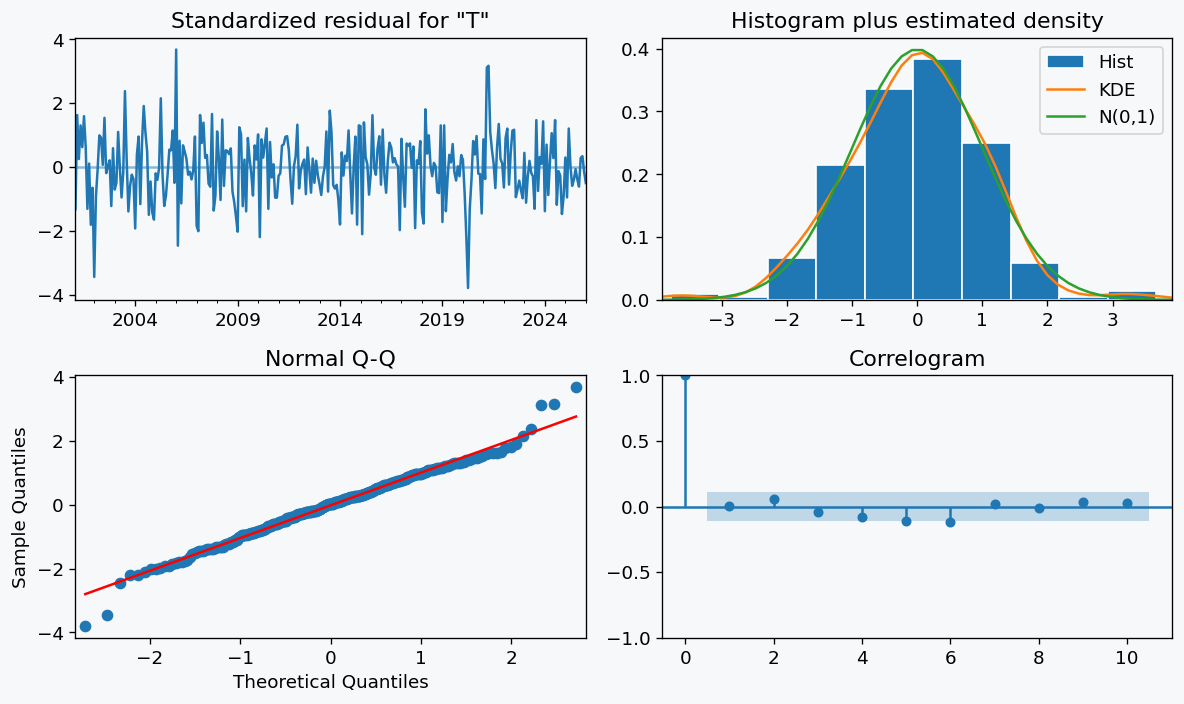

In [26]:
# Obtain diagnostic plots
fig = theft_sarima.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

The residuals are centered around zero and do not show a clear trend or repeating pattern. Most autocorrelation values are within the confidence interval, suggesting that the model captured most of the time-series structure. The histogram and Q–Q plot are approximately normal, although a few extreme residuals cause deviations in the tails. Overall, the diagnostics support using the model, but the forecast confidence intervals should be interpreted carefully because of these outliers.

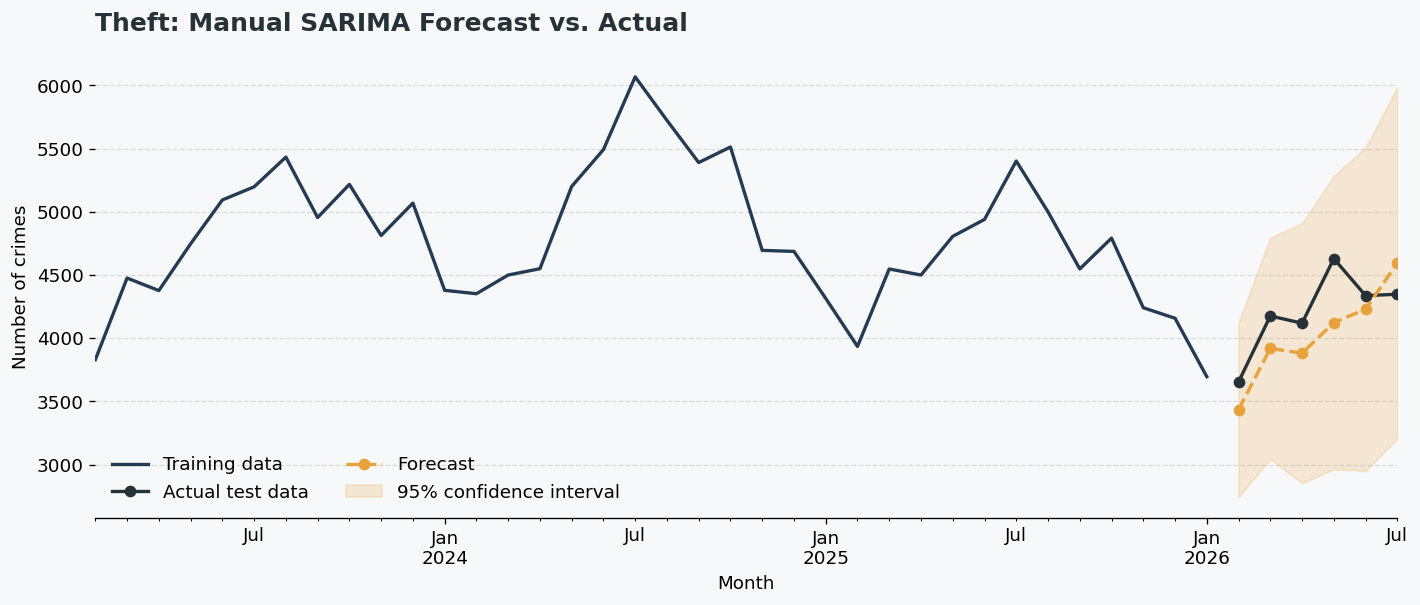

,MAE,RMSE,MAPE (%),R²
Model,,,,
Manual SARIMA,262.49,288.58,6.17,0.06


In [27]:
# Forecast the 6 test months
theft_manual_prediction = theft_sarima.get_forecast(
    steps=TEST_MONTHS
)

# Create the forecast DataFrame
theft_manual_forecast = theft_manual_prediction.summary_frame()
theft_manual_forecast.index = theft_test.index

# Plot forecast against actual test data
plot_forecast(
    theft_train,
    theft_test,
    theft_manual_forecast,
    n_train_lags=36,
    title="Theft: Manual SARIMA Forecast vs. Actual",
)

# Calculate evaluation metrics
theft_manual_metrics = regression_metrics(
    theft_test,
    theft_manual_forecast["mean"],
    model_name="Manual SARIMA",
)

display(
    pd.DataFrame([theft_manual_metrics])
    .set_index("Model")
    .round(2)
)

### 1.4 Theft: Tune with `auto_arima`

In [28]:
theft_auto_search = pm.auto_arima(
    theft_train,
    seasonal=theft_use_seasonal,
    m=SEASON_LENGTH if theft_use_seasonal else 1,
    d=theft_d,
    D=theft_D,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    information_criterion="aic",
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True,
)

theft_auto_order = theft_auto_search.order
theft_auto_seasonal_order = theft_auto_search.seasonal_order

print(f"Best order: {theft_auto_order}")
print(f"Best seasonal order: {theft_auto_seasonal_order}")
print(f"Best AIC: {theft_auto_search.aic():,.2f}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4700.245, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=4402.491, Time=1.74 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=4549.972, Time=2.33 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4698.404, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=4700.286, Time=0.04 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=4375.092, Time=2.42 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=4338.060, Time=4.40 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=4337.893, Time=2.75 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=4548.682, Time=1.13 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=4337.605, Time=3.23 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=4493.349, Time=0.68 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.18 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=4354.506, Time=1.72 sec
 ARIMA(2,1,0)(1,0,2)[12] intercept   : AIC=4340.534, Time=1.91 sec
 ARIMA(1,1,1)(1,0,2)[12]

In [29]:
theft_auto_model = tsa.ARIMA(theft_train, order=theft_auto_order, seasonal_order=theft_auto_seasonal_order).fit()

In [30]:
theft_auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                       
=============================================================================================
Dep. Variable:                                 Theft   No. Observations:                  301
Model:             ARIMA(1, 1, 0)x(1, 0, [1, 2], 12)   Log Likelihood               -2163.034
Date:                               Fri, 11 Sep 2026   AIC                           4336.067
Time:                                       21:10:59   BIC                           4354.586
Sample:                                   01-01-2001   HQIC                          4343.478
                                        - 01-01-2026                                         
Covariance Type:                                 opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2424      0.041     -5.845      0.000      -0.324      -0.161
ar.S.L12       0.9806      0.007    150.597      0.000       0.968       0.993
ma.S.L12      -0.6156      0.055    -11.161      0.000      -0.724      -0.507
ma.S.L24      -0.0930      0.062     -1.489      0.136      -0.215       0.029
sigma2      9.546e+04   6081.836     15.696      0.000    8.35e+04    1.07e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                45.68
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               0.73   Skew:                            -0.44
Prob(H) (two-sided):                  0.11   Kurtosis:                         4.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

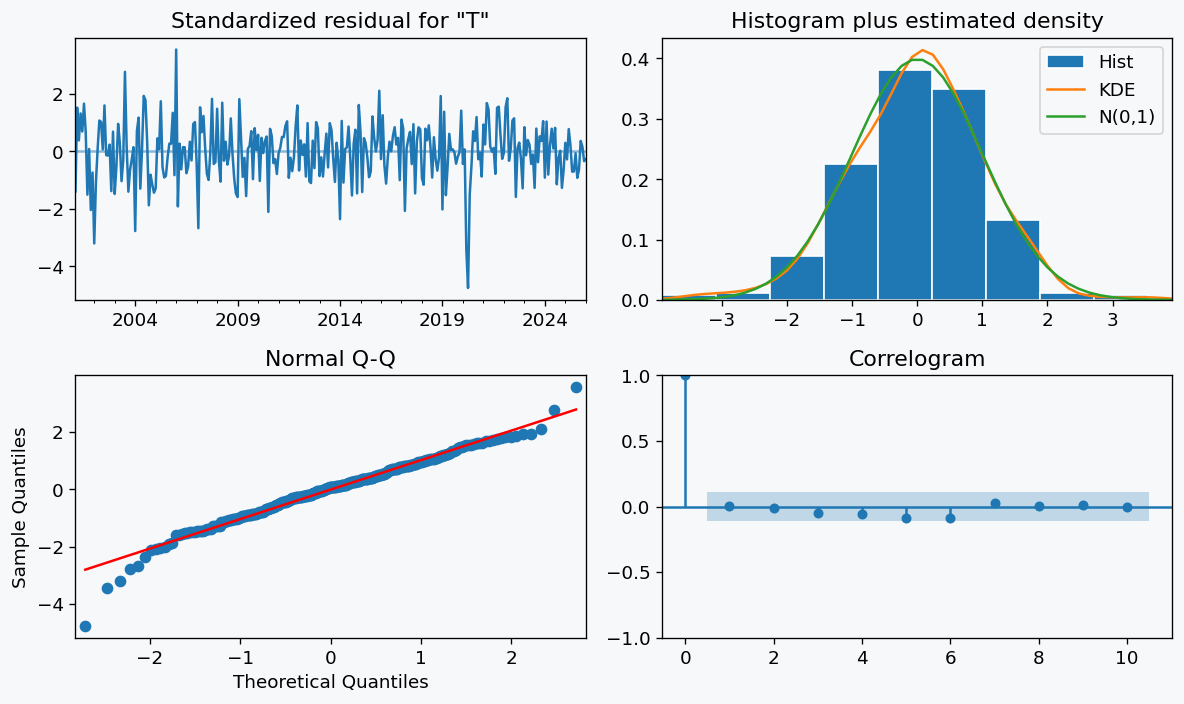

In [31]:
# Obtain diagnostic plots
fig = theft_auto_model.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

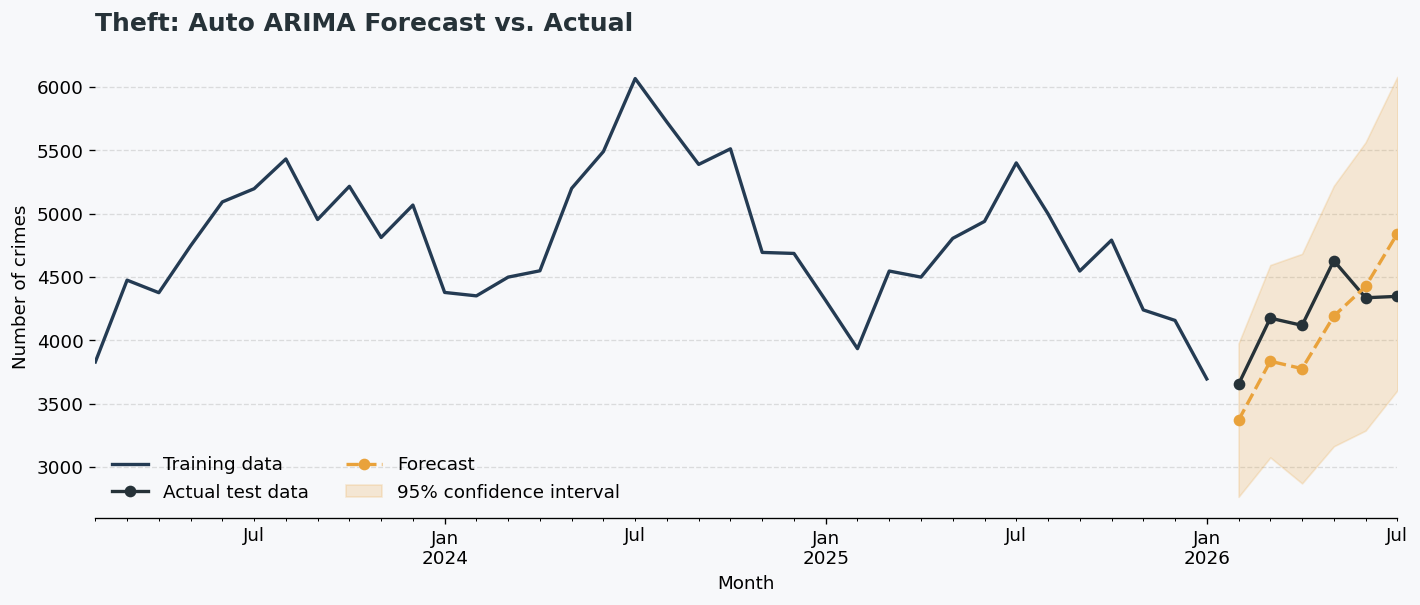

,MAE,RMSE,MAPE (%),R²
Model,,,,
Manual SARIMA,262.49,288.58,6.17,0.06
Auto ARIMA,331.29,355.39,7.85,-0.43


In [32]:
# Forecast the 6 test months
theft_auto_prediction = theft_auto_model.get_forecast(
    steps=TEST_MONTHS
)

# Create the forecast DataFrame
theft_auto_forecast = theft_auto_prediction.summary_frame()
theft_auto_forecast.index = theft_test.index

# Plot forecast against actual test data
plot_forecast(
    theft_train,
    theft_test,
    theft_auto_forecast,
    n_train_lags=36,
    title="Theft: Auto ARIMA Forecast vs. Actual",
)

# Calculate evaluation metrics
theft_auto_metrics = regression_metrics(
    theft_test,
    theft_auto_forecast["mean"],
    model_name="Auto ARIMA",
)

# Compare both models
theft_metrics = pd.DataFrame([
    theft_manual_metrics,
    theft_auto_metrics,
]).set_index("Model")

display(theft_metrics.round(2))

### 1.5 Theft: Select the Final Model and Forecast the Future

The **Manual SARIMA** model was selected because it performed better on the test data. It had lower MAE (262.49), RMSE (288.58), and MAPE (6.17%) than Auto ARIMA. Although Auto ARIMA had a lower AIC, its test errors were higher and its R² was negative. Therefore, the manual model provides more accurate forecasts for unseen data.


In [33]:
final_p = 0
final_q = 1
final_d = 1
final_P = 1
final_Q = 0
final_D = 0

theft_final_model = tsa.ARIMA(
    theft_ts,
    order=(final_p, final_d, final_q),
    seasonal_order=(final_P, final_D, final_Q, SEASON_LENGTH),
).fit()

In [34]:
# Forecast 6 months beyond the dataset
theft_future_prediction = theft_final_model.get_forecast(
    steps=TEST_MONTHS
)

theft_future = theft_future_prediction.summary_frame()

# Add the correct future dates
theft_future.index = pd.date_range(
    start=theft_ts.index[-1] + pd.offsets.MonthBegin(1),
    periods=TEST_MONTHS,
    freq="MS",
)

display(theft_future.round(2))

Theft,mean,mean_se,mean_ci_lower,mean_ci_upper
2026-08-01,4123.57,350.48,3436.64,4810.50
2026-09-01,3766.43,444.98,2894.28,4638.58
2026-10-01,3959.22,522.67,2934.81,4983.64
2026-11-01,3523.86,590.22,2367.05,4680.67
2026-12-01,3458.28,650.79,2182.74,4733.81
2027-01-01,3093.23,706.19,1709.12,4477.35


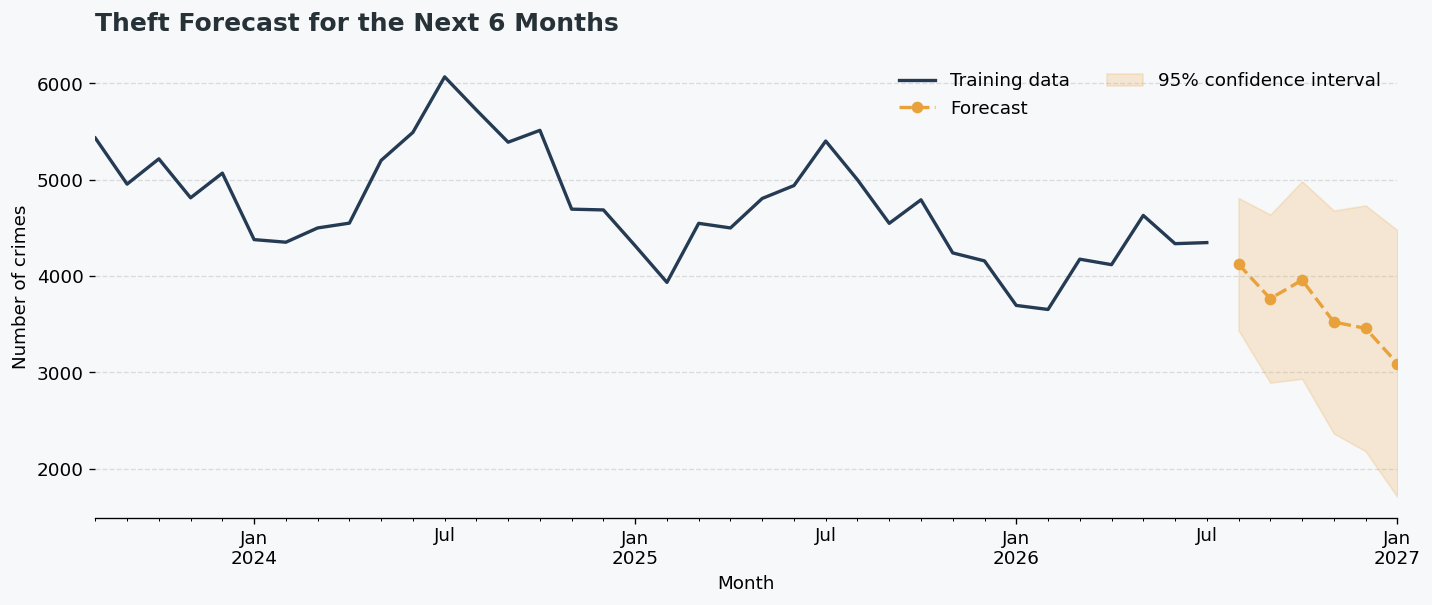

In [35]:
plot_forecast(
    theft_ts,
    None,
    theft_future,
    n_train_lags=36,
    title="Theft Forecast for the Next 6 Months",
);

In [36]:
# Define the beginning and final forecast values
starting_value = theft_future["mean"].iloc[0]
final_value = theft_future["mean"].iloc[-1]

# Calculate the net change
delta = final_value - starting_value

# Calculate the percentage change
percent_change = (delta / starting_value) * 100

print(f"Beginning forecast: {starting_value:,.0f} crimes")
print(f"Final forecast: {final_value:,.0f} crimes")
print(f"Net change in Theft: {delta:+,.0f} crimes")
print(f"Percentage change: {percent_change:+.2f}%")

Beginning forecast: 4,124 crimes
Final forecast: 3,093 crimes
Net change in Theft: -1,030 crimes
Percentage change: -24.99%


## 2. Battery Forecast


### 2.1 Battery: Seasonality and Decomposition

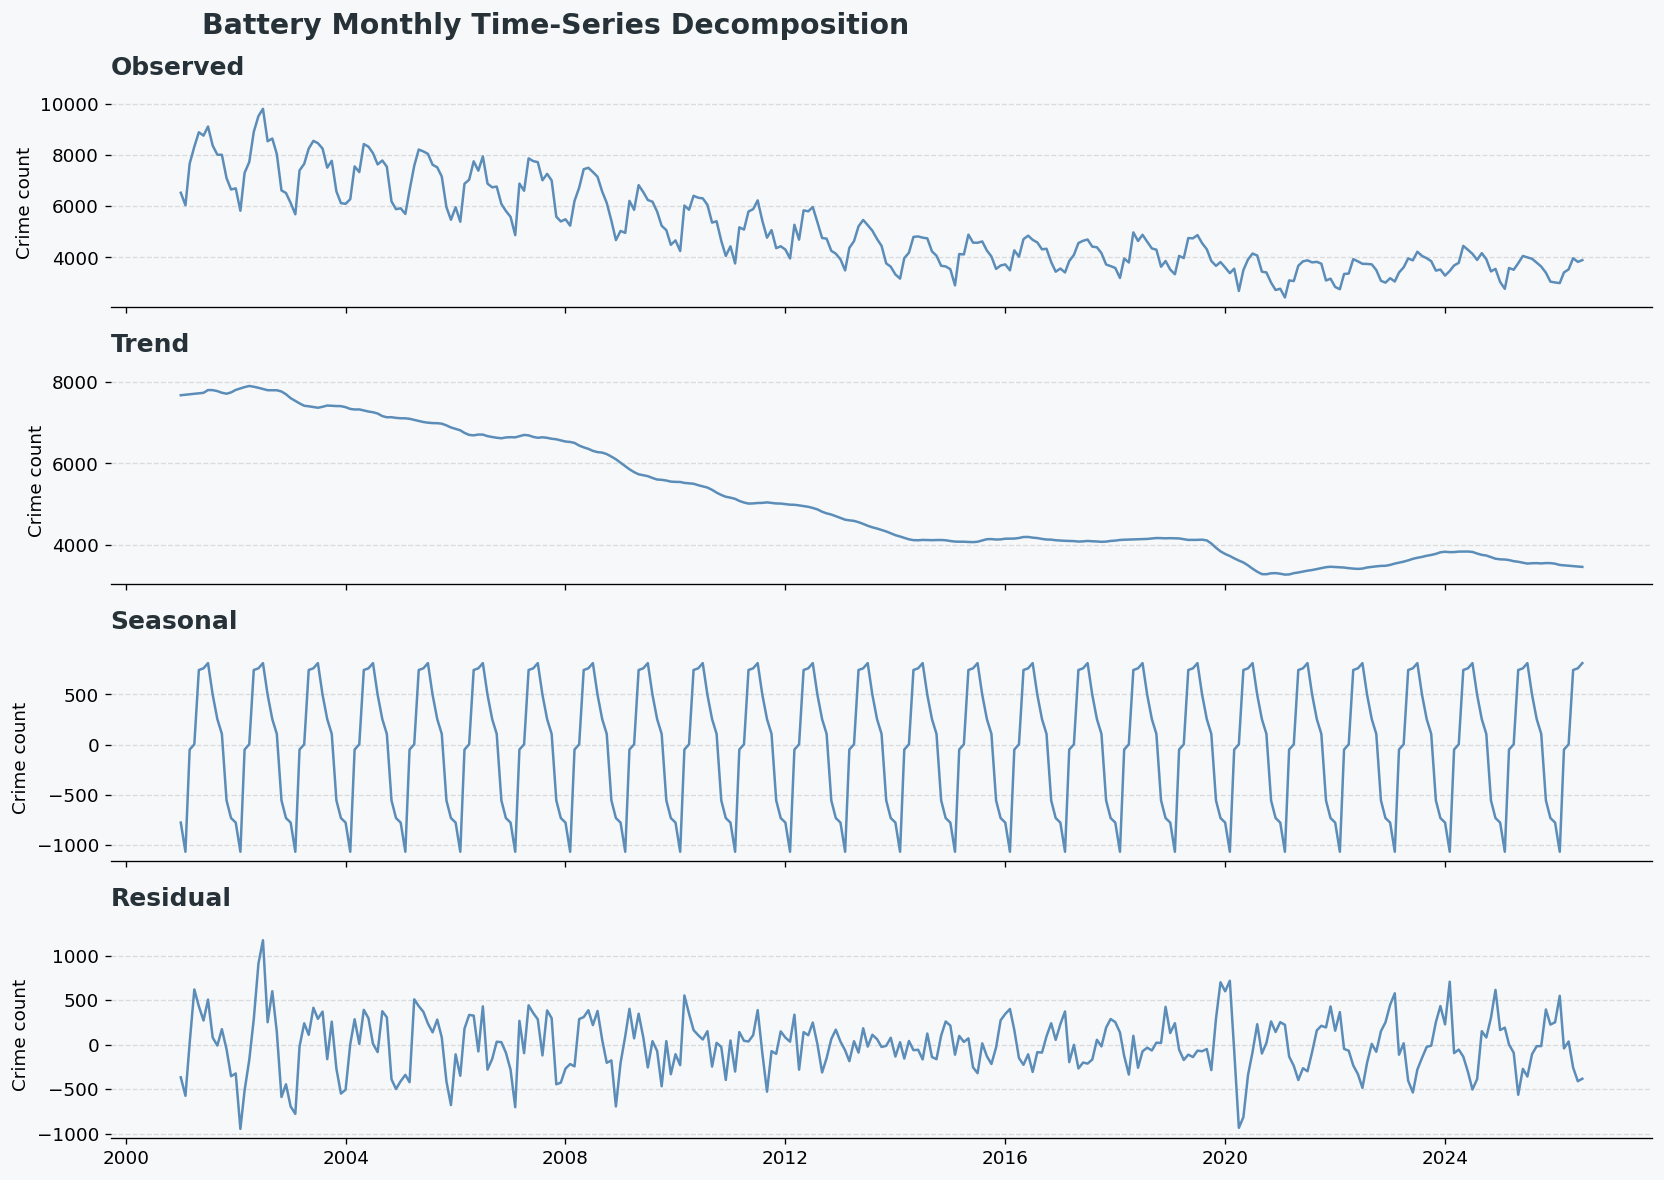

Seasonal strength: 0.805
Use a seasonal model? True


In [37]:
battery_ts = crime_series["BATTERY"]
battery_decomposition = seasonal_decompose(
    battery_ts,
    model="additive",
    period=SEASON_LENGTH,
    extrapolate_trend="freq",
)

plot_decomposition(
    battery_decomposition,
    crime_name="BATTERY",
    color=CRIME_COLORS["BATTERY"],
)

battery_seasonal_strength = max(
    0,
    1 - (
        battery_decomposition.resid.dropna().var()
        / (battery_decomposition.seasonal + battery_decomposition.resid).dropna().var()
    ),
)

battery_use_seasonal = battery_seasonal_strength >= 0.10
print(f"Seasonal strength: {battery_seasonal_strength:.3f}")
print(f"Use a seasonal model? {battery_use_seasonal}")

**Seasonality decision:** The decomposition is checked for a repeating 12-month pattern. A seasonal SARIMA structure is tested because monthly Battery counts may follow recurring yearly conditions. The six-month test performance determines whether that structure is useful in practice.

### 2.2 Battery: Differencing, Stationarity, ACF, and PACF

Recommended nonseasonal differences (d): 1
Recommended seasonal differences (D): 0


,ADF statistic,p-value,Lags used,Observations,Stationary?
Series,,,,,
Differenced Battery,-4.456978,0.000235,14,291,True


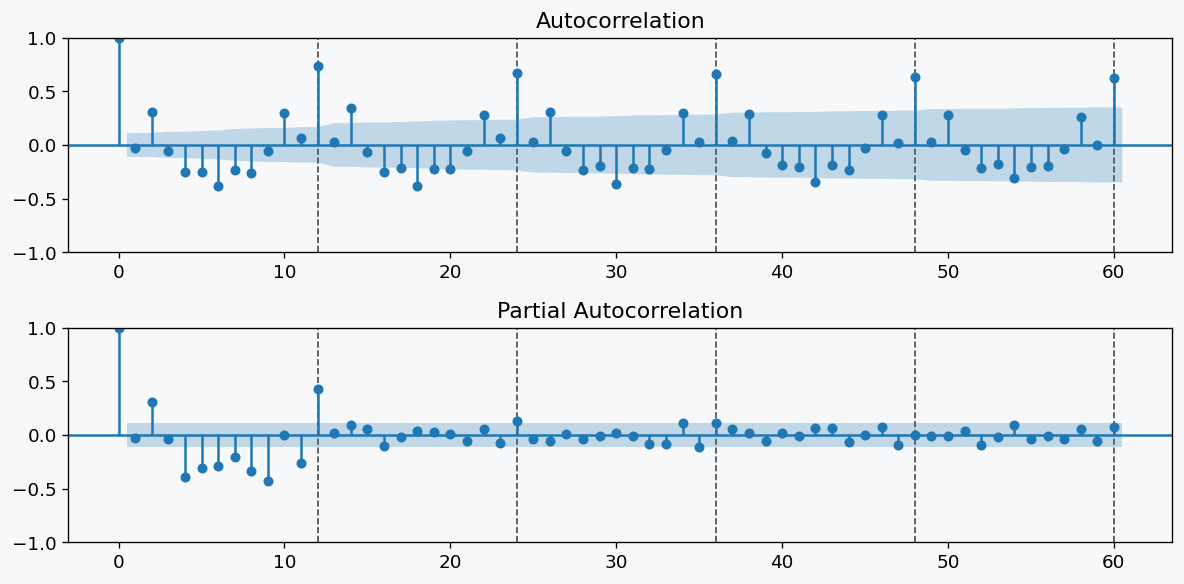

In [38]:
battery_d = ndiffs(battery_ts)
battery_D = nsdiffs(battery_ts, m=SEASON_LENGTH)

battery_stationary = make_stationary(
    battery_ts,
    d=battery_d,
    D=battery_D,
    season_length=SEASON_LENGTH,
)

print(f"Recommended nonseasonal differences (d): {battery_d}")
print(f"Recommended seasonal differences (D): {battery_D}")
display(adf_summary(battery_stationary, "Differenced Battery"))

plot_acf_pacf(battery_stationary, annotate_seas=True, m = SEASON_LENGTH, nlags=60);


SEASONAL: 1,D,0
ARIMA: 1,d,1

In [39]:
MANUAL_ORDERS = {
    "THEFT": {"p": 0, "q": 1, "P": 1, "Q": 0},
    "BATTERY": {"p": 1, "q": 0, "P": 1, "Q": 1},
}

### 2.3 Battery: Train/Test Split and Manual SARIMA

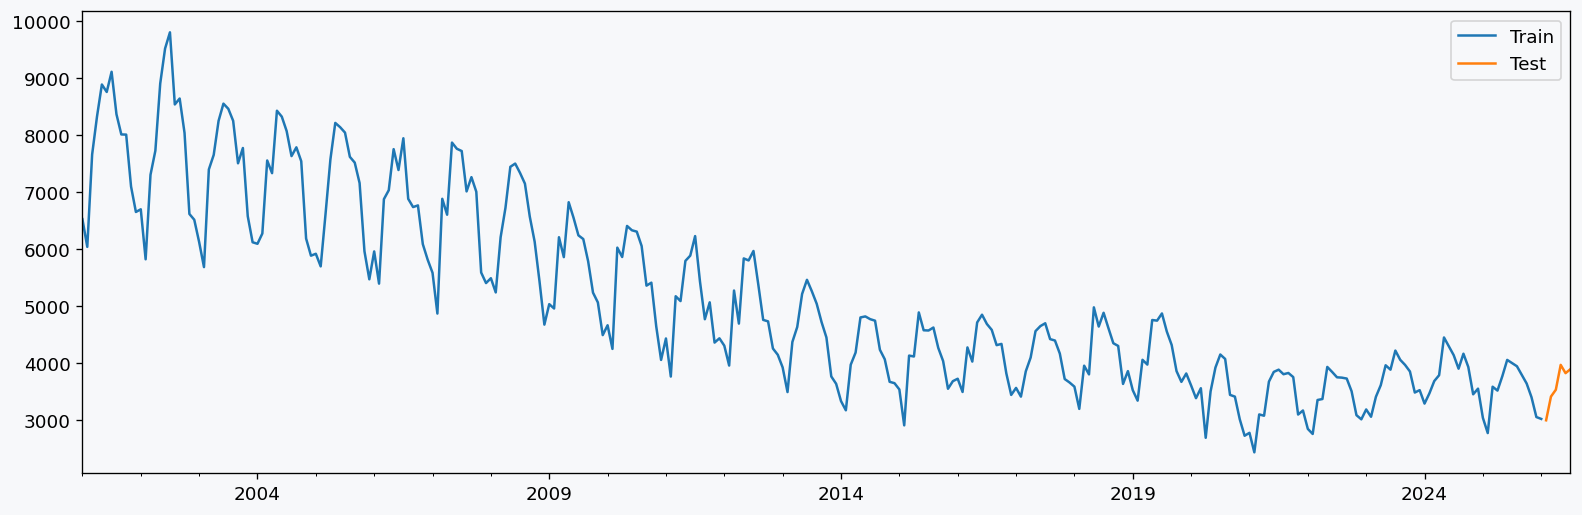

In [40]:
# tts
battery_train, battery_test = train_test_split(battery_ts, test_size=TEST_MONTHS)
ax = battery_train.plot(label='Train')
battery_test.plot(ax=ax, label='Test')
ax.legend();

In [41]:
battery_settings = MANUAL_ORDERS["BATTERY"]
battery_manual_order = (
    battery_settings["p"], battery_d, battery_settings["q"]
)

battery_manual_seasonal_order = (
    battery_settings["P"], battery_D, battery_settings["Q"], SEASON_LENGTH
) if battery_use_seasonal else (0, 0, 0, 0)

print(f"Training months: {len(battery_train)}")
print(f"Test months: {len(battery_test)}")
print(f"Manual order: {battery_manual_order}")
print(f"Manual seasonal order: {battery_manual_seasonal_order}")

Training months: 301
Test months: 6
Manual order: (1, 1, 0)
Manual seasonal order: (1, 0, 1, 12)


In [42]:
battery_sarima = tsa.ARIMA(battery_train, order=battery_manual_order, seasonal_order=battery_manual_seasonal_order).fit()

In [43]:
battery_sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            Battery   No. Observations:                  301
Model:             ARIMA(1, 1, 0)x(1, 0, [1], 12)   Log Likelihood               -2128.511
Date:                            Fri, 11 Sep 2026   AIC                           4265.022
Time:                                    21:11:02   BIC                           4279.837
Sample:                                01-01-2001   HQIC                          4270.951
                                     - 01-01-2026                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3171      0.048     -6.552      0.000      -0.412      -0.222
ar.S.L12       0.9837      0.005    182.613      0.000       0.973       0.994
ma.S.L12      -0.7014      0.049    -14.361      0.000      -0.797      -0.606
sigma2      7.641e+04   6042.723     12.645      0.000    6.46e+04    8.83e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.31   Jarque-Bera (JB):                 2.51
Prob(Q):                              0.58   Prob(JB):                         0.29
Heteroskedasticity (H):               0.40   Skew:                            -0.04
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.44
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

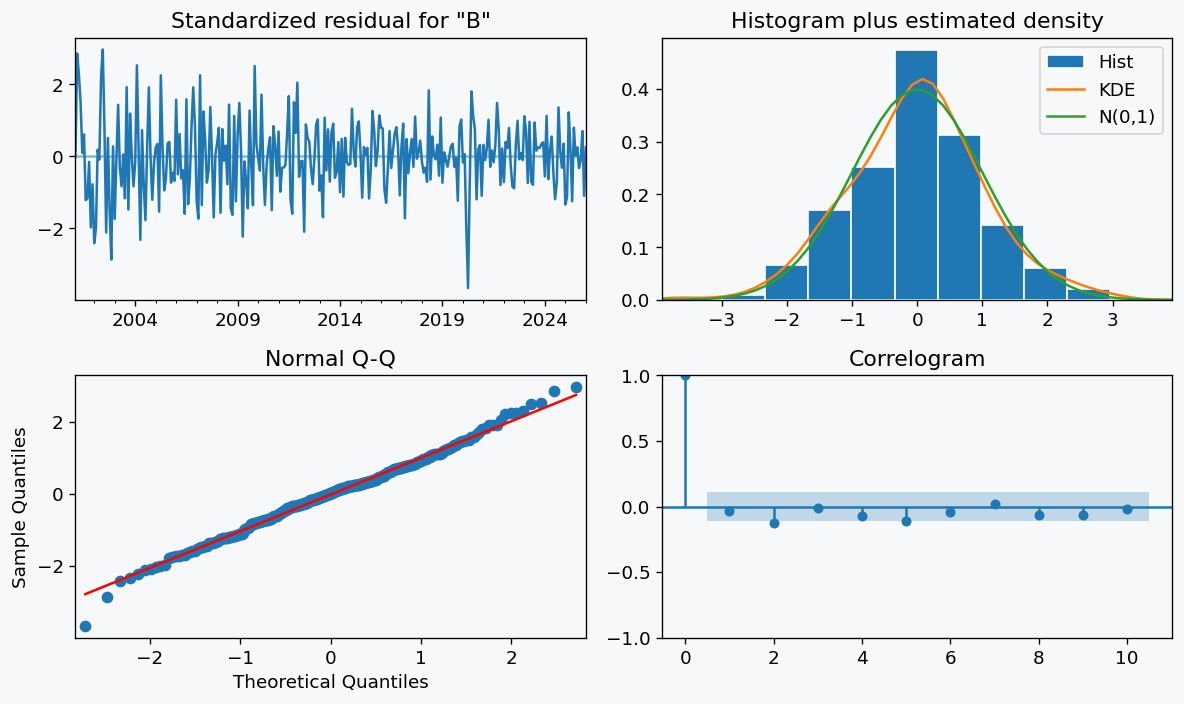

In [44]:
# Obtain diagnostic plots
fig =battery_sarima.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

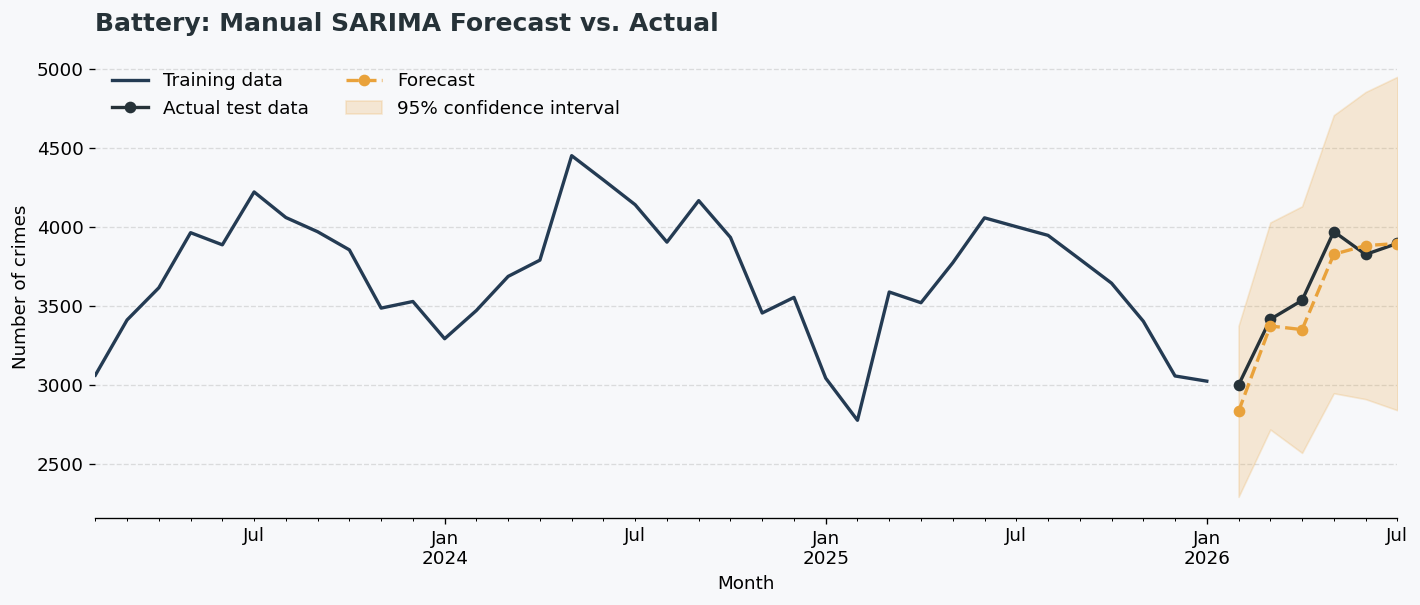

,MAE,RMSE,MAPE (%),R²
Model,,,,
Manual SARIMA,99.25,121.01,2.86,0.87


In [45]:
# Forecast the 6 test months
battery_manual_prediction = battery_sarima.get_forecast(
    steps=TEST_MONTHS
)

# Create the forecast DataFrame
battery_manual_forecast = battery_manual_prediction.summary_frame()
battery_manual_forecast.index = battery_test.index

# Plot forecast against actual test data
plot_forecast(
    battery_train,
    battery_test,
    battery_manual_forecast,
    n_train_lags=36,
    title="Battery: Manual SARIMA Forecast vs. Actual",
)

# Calculate evaluation metrics
battery_manual_metrics = regression_metrics(
    battery_test,
    battery_manual_forecast["mean"],
    model_name="Manual SARIMA",
)

display(
    pd.DataFrame([battery_manual_metrics])
    .set_index("Model")
    .round(2)
)

### 2.4 Battery: Tune with `auto_arima`

In [46]:
battery_auto_search = pm.auto_arima(
    battery_train,
    seasonal=battery_use_seasonal,
    m=SEASON_LENGTH if battery_use_seasonal else 1,
    d=battery_d,
    D=battery_D,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    information_criterion="aic",
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True,
)

battery_auto_order = battery_auto_search.order
battery_auto_seasonal_order = battery_auto_search.seasonal_order

print(f"Best order: {battery_auto_order}")
print(f"Best seasonal order: {battery_auto_seasonal_order}")
print(f"Best AIC: {battery_auto_search.aic():,.2f}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4632.630, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=4353.118, Time=0.28 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=4489.212, Time=0.28 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4630.771, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=4634.164, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=1.43 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=4266.744, Time=0.74 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=4487.186, Time=0.24 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=4268.660, Time=1.85 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=4268.612, Time=1.79 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=4448.465, Time=2.04 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.72 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=4296.521, Time=0.66 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : AIC=4262.384, Time=1.06 sec
 ARIMA(2,1,0)(0,0,1)[12] inte

In [47]:
battery_auto_model = tsa.ARIMA(battery_train, order=battery_auto_order, seasonal_order=battery_auto_seasonal_order).fit()

In [48]:
battery_auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            Battery   No. Observations:                  301
Model:             ARIMA(2, 1, 0)x(1, 0, [1], 12)   Log Likelihood               -2125.310
Date:                            Fri, 11 Sep 2026   AIC                           4260.620
Time:                                    21:11:55   BIC                           4279.139
Sample:                                01-01-2001   HQIC                          4268.032
                                     - 01-01-2026                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3731      0.051     -7.315      0.000      -0.473      -0.273
ar.L2         -0.1478      0.051     -2.917      0.004      -0.247      -0.048
ar.S.L12       0.9844      0.005    193.402      0.000       0.974       0.994
ma.S.L12      -0.6819      0.051    -13.486      0.000      -0.781      -0.583
sigma2      7.395e+04   5834.298     12.674      0.000    6.25e+04    8.54e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 3.44
Prob(Q):                              0.96   Prob(JB):                         0.18
Heteroskedasticity (H):               0.41   Skew:                            -0.01
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

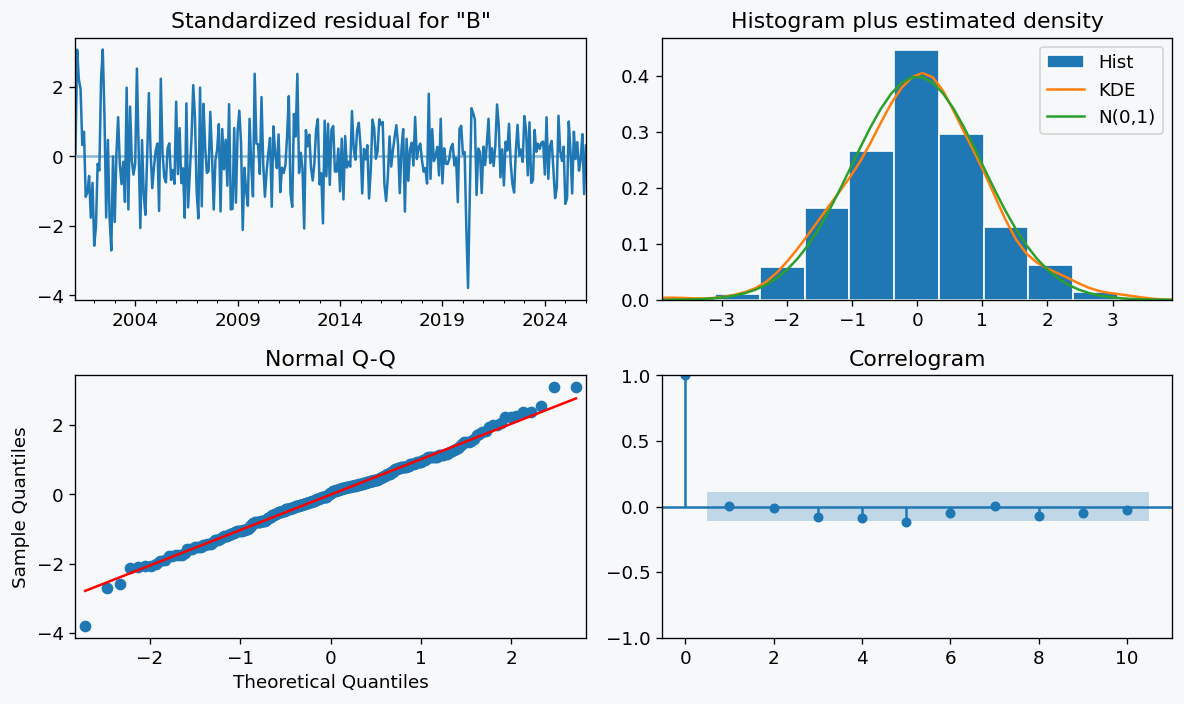

In [49]:
# Obtain diagnostic plots
fig = battery_auto_model.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

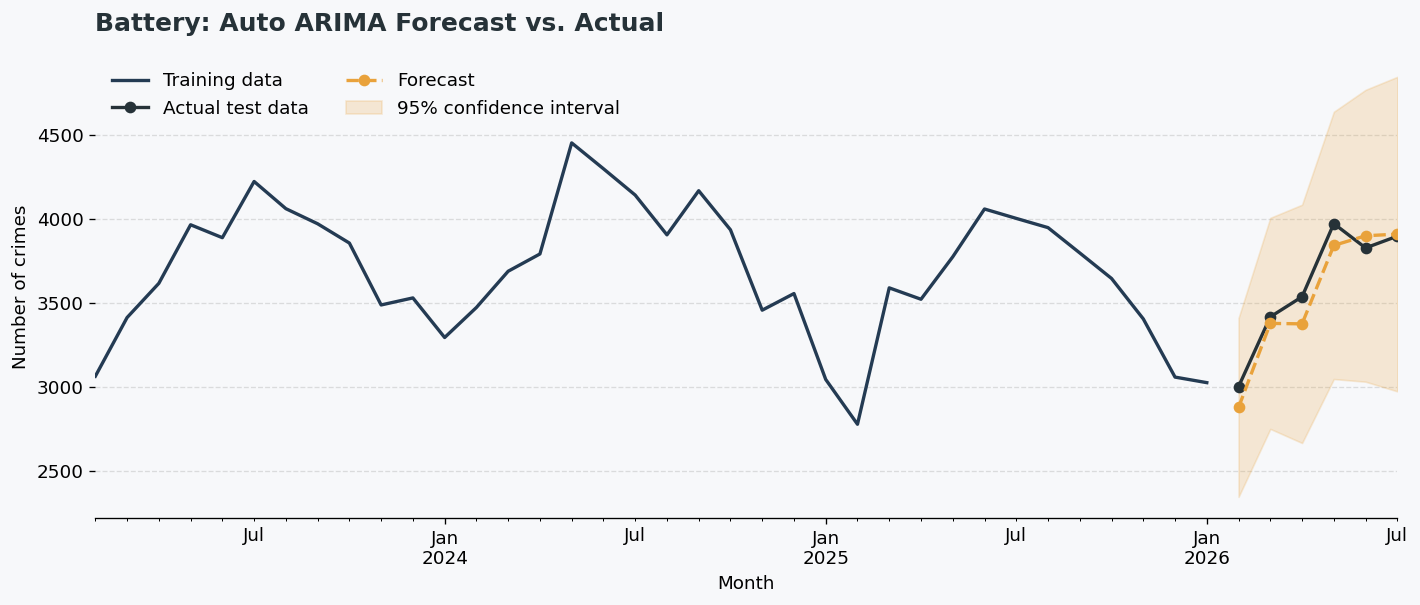

,MAE,RMSE,MAPE (%),R²
Model,,,,
Manual SARIMA,99.25,121.01,2.86,0.87
Auto ARIMA,89.86,104.32,2.55,0.90


In [50]:
# Forecast the 6 test months
battery_auto_prediction = battery_auto_model.get_forecast(
    steps=TEST_MONTHS
)

# Create the forecast DataFrame
battery_auto_forecast = battery_auto_prediction.summary_frame()
battery_auto_forecast.index = battery_test.index

# Plot forecast against actual test data
plot_forecast(
    battery_train,
    battery_test,
    battery_auto_forecast,
    n_train_lags=36,
    title="Battery: Auto ARIMA Forecast vs. Actual",
)

# Calculate evaluation metrics
battery_auto_metrics = regression_metrics(
    battery_test,
    battery_auto_forecast["mean"],
    model_name="Auto ARIMA",
)

# Compare both models
battery_metrics = pd.DataFrame([
    battery_manual_metrics,
    battery_auto_metrics,
]).set_index("Model")

display(battery_metrics.round(2))

**Auto ARIMA** as the final model because it performed better across all evaluation metrics. It achieved lower **MAE (89.86)**, **RMSE (104.32)**, and **MAPE (2.55%)**, meaning its predictions were closer to the actual values. It also had a higher **R² score of 0.90**, explaining approximately 90% of the variation in the test data.


### 2.5 Battery: Select the Final Model and Forecast the Future

In [51]:
final_p = 2
final_q = 0
final_d = 1
final_P = 1
final_Q = 1
final_D = 0

battery_final_model = tsa.ARIMA(
    battery_ts,
    order=(final_p, final_d, final_q),
    seasonal_order=(final_P, final_D, final_Q, SEASON_LENGTH),
).fit()

In [52]:
# Forecast 6 months beyond the dataset
battery_future_prediction = battery_final_model.get_forecast(
    steps=TEST_MONTHS
)

battery_future = battery_future_prediction.summary_frame()

# Add the correct future dates
battery_future.index = pd.date_range(
    start=battery_ts.index[-1] + pd.offsets.MonthBegin(1),
    periods=TEST_MONTHS,
    freq="MS",
)

display(battery_future.round(2))

Battery,mean,mean_se,mean_ci_lower,mean_ci_upper
2026-08-01,3783.46,269.59,3255.07,4311.84
2026-09-01,3714.60,318.03,3091.28,4337.93
2026-10-01,3558.79,358.60,2855.95,4261.63
2026-11-01,3192.80,402.17,2404.56,3981.04
2026-12-01,3101.16,439.16,2240.42,3961.89
2027-01-01,2935.79,473.13,2008.48,3863.11


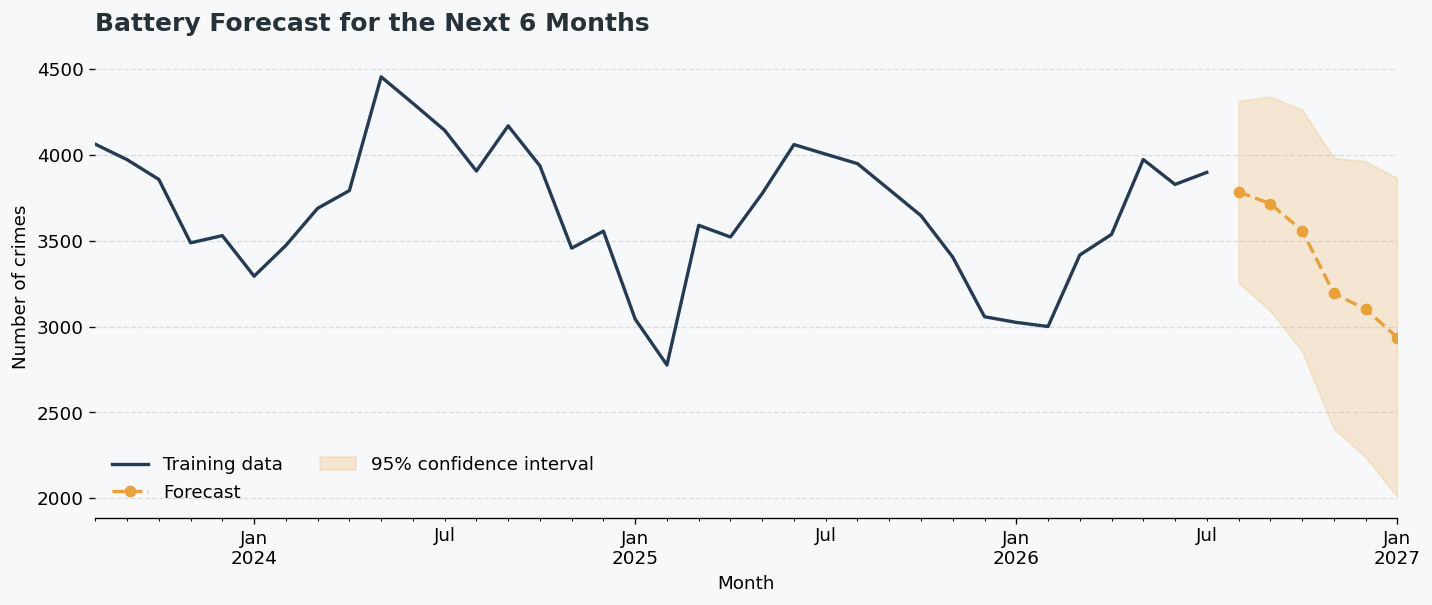

In [53]:
plot_forecast(
    battery_ts,
    None,
    battery_future,
    n_train_lags=36,
    title="Battery Forecast for the Next 6 Months",
);

In [54]:
# Define the beginning and final forecast values
starting_value = battery_future["mean"].iloc[0]
final_value = battery_future["mean"].iloc[-1]

# Calculate the net change
delta = final_value - starting_value

# Calculate the percentage change
percent_change = (delta / starting_value) * 100

print(f"Beginning forecast: {starting_value:,.0f} crimes")
print(f"Final forecast: {final_value:,.0f} crimes")
print(f"Net change in Battery: {delta:+,.0f} crimes")
print(f"Percentage change: {percent_change:+.2f}%")

Beginning forecast: 3,783 crimes
Final forecast: 2,936 crimes
Net change in Battery: -848 crimes
Percentage change: -22.40%


## Final Evaluation

In [56]:
# Compare the first and final month of both forecasts
forecast_comparison = pd.DataFrame({
    "Crime": ["Theft", "Battery"],
    "Beginning Forecast": [
        theft_future["mean"].iloc[0],
        battery_future["mean"].iloc[0]
    ],
    "Final Forecast": [
        theft_future["mean"].iloc[-1],
        battery_future["mean"].iloc[-1]
    ],
})

# Calculate the net change
forecast_comparison["Net Change"] = (
    forecast_comparison["Final Forecast"]
    - forecast_comparison["Beginning Forecast"]
)

# Calculate the percent change
forecast_comparison["Percent Change"] = (
    forecast_comparison["Net Change"]
    / forecast_comparison["Beginning Forecast"]
) * 100

display(forecast_comparison.set_index("Crime").round(2))

,Beginning Forecast,Final Forecast,Net Change,Percent Change
Crime,,,,
Theft,4123.57,3093.23,-1030.34,-24.99
Battery,3783.46,2935.79,-847.66,-22.40


**Comparison of the Six-Month Forecasts**

- **Highest monthly count at the end of the forecast:** **Theft**, with approximately **3,093 crimes**, compared with **2,936 Battery crimes**.

- **Highest net change:** **Battery**, with a change of approximately **−848 crimes**, compared with **−1,030 crimes for Theft**. Both crimes are forecasted to decrease, but Battery has the higher net change because its decrease is smaller.

- **Highest percent change:** **Battery**, with approximately **−22.40%**, compared with **−24.99% for Theft**. Therefore, Battery is forecasted to have the smaller percentage decrease.

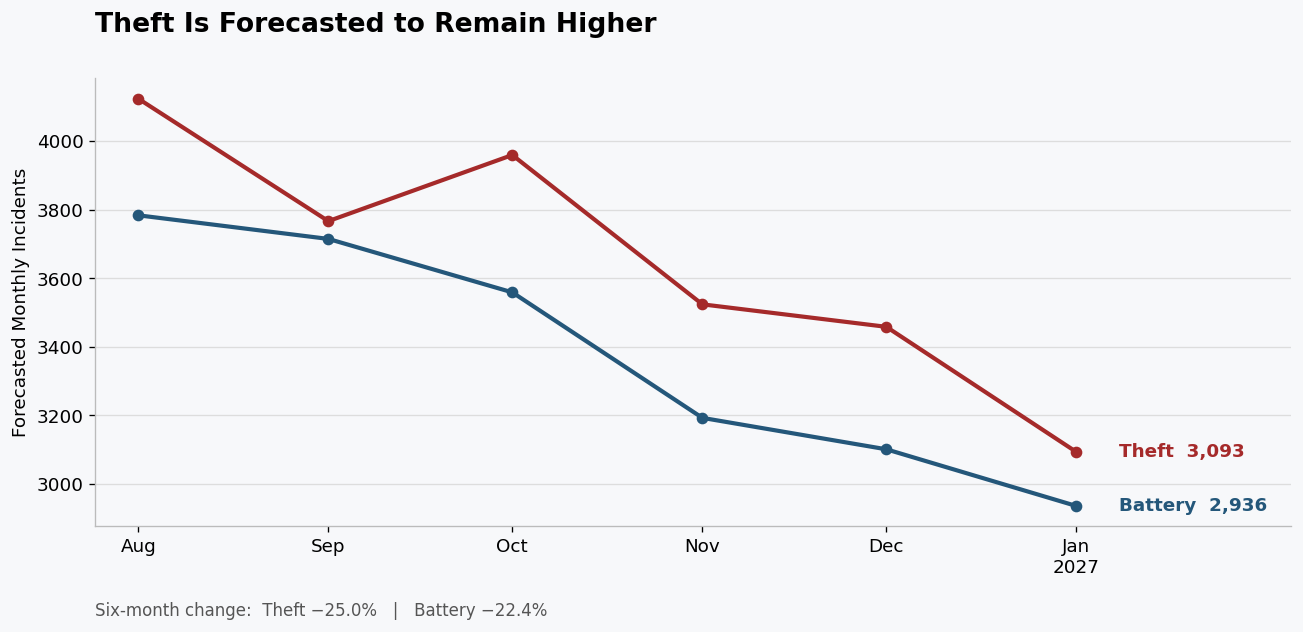

In [62]:
# Colors for each crime
theft_color = "#A52A2A"
battery_color = "#24577A"

# Create the chart
fig, ax = plt.subplots(figsize=(11, 5.5))

# Plot both forecasts
ax.plot(
    theft_future.index,
    theft_future["mean"],
    color=theft_color,
    linewidth=2.5,
    marker="o",
    markersize=6,
)

ax.plot(
    battery_future.index,
    battery_future["mean"],
    color=battery_color,
    linewidth=2.5,
    marker="o",
    markersize=6,
)

# Get the final forecast values
theft_final = theft_future["mean"].iloc[-1]
battery_final = battery_future["mean"].iloc[-1]

# Label each line directly
ax.text(
    theft_future.index[-1] + pd.Timedelta(days=7),
    theft_final,
    f"Theft  {theft_final:,.0f}",
    color=theft_color,
    fontweight="bold",
    va="center",
)

ax.text(
    battery_future.index[-1] + pd.Timedelta(days=7),
    battery_final,
    f"Battery  {battery_final:,.0f}",
    color=battery_color,
    fontweight="bold",
    va="center",
)

# Title and subtitle
ax.set_title(
    "Theft Is Forecasted to Remain Higher",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=28,
)

# Format the axes
ax.set_ylabel("Forecasted Monthly Incidents")
ax.set_xlabel("")

ax.set_xticks(theft_future.index)
ax.set_xticklabels(
    ["Aug", "Sep", "Oct", "Nov", "Dec", "Jan\n2027"]
)

# Add space for the labels
ax.set_xlim(
    theft_future.index[0] - pd.Timedelta(days=7),
    theft_future.index[-1] + pd.Timedelta(days=35),
)

# Add the forecasted changes as a note
ax.text(
    0,
    -0.20,
    "Six-month change:  Theft −25.0%   |   Battery −22.4%",
    transform=ax.transAxes,
    fontsize=10,
    color="#555555",
)

# Clean styling
ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#BBBBBB")

plt.tight_layout()
plt.show()

**Recommendation**

Chicago public safety teams should focus more resources on **Theft** because it is expected to remain higher than Battery. However, they should continue monitoring both crimes and update the forecasts when new data is available.
